# Introducción al análisis frecuencial de señales
## Práctica 5

**Integrantes:**  
- Sara Mejía Zapata  
- María Camila Tobón Úsuga

**Asignatura:** Bioseñales y Sistemas


---

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Ejemplo de la práctica 


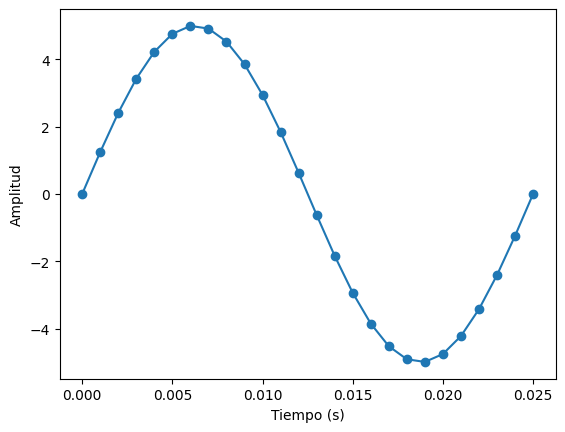

In [13]:
Fo = 40 # Frecuencia fundamental de la señal
Tp = 1/Fo # Periodo de la señal
Fs = 1000 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más una muestra T
A = 5
x = A*np.sin(2*np.pi*Fo*t)
plt.plot(t, x, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()


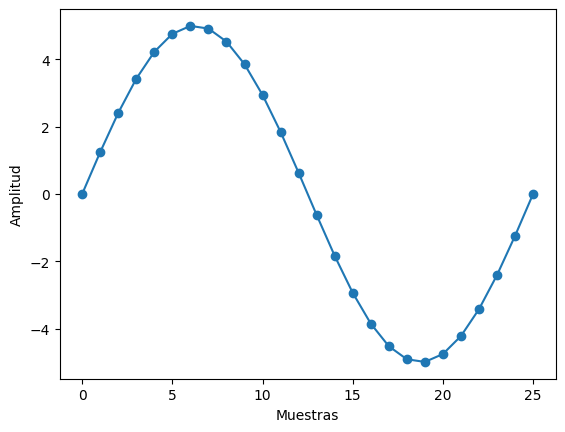

In [14]:
fo = Fo/Fs
n = np.arange(0, len(t))
x1 = A*np.sin(2*np.pi*fo*n)
plt.plot(n, x1, marker='o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


a)	Compruebe que los valores de las primeras cinco muestras son los mismos

In [15]:
print("Primeras cinco muestras de x:")
print(x[:5])

print("Primeras cinco muestras de x1:")
print(x1[:5])

Primeras cinco muestras de x:
[0.         1.24344944 2.40876837 3.42273553 4.22163963]
Primeras cinco muestras de x1:
[0.         1.24344944 2.40876837 3.42273553 4.22163963]


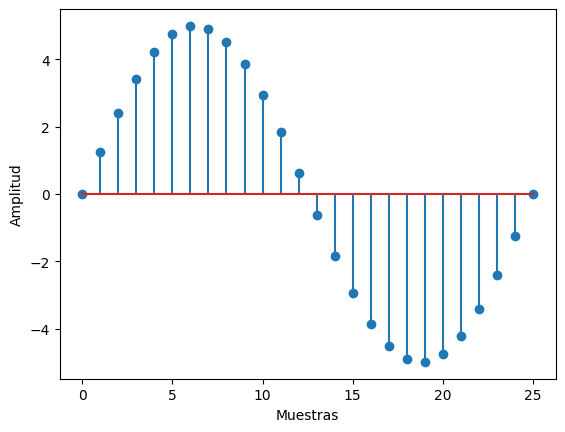

In [16]:

fo = Fo/Fs
n = np.arange(0, len(t))
x1 = A*np.sin(2*np.pi*fo*n)
plt.stem(n, x1, markerfmt='o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


In [17]:
##energia de la señal en un ciclo
energia = sum(x**2)
print(energia)
#La potencia media de la señal medida en W es en un ciclo:
potencia = energia/(len(t)-1)
print(potencia)
##El valor cuadrático medio es la raíz cuadrada de la potencia:
rms = np.sqrt(potencia)
print(rms)

312.50000000000006
12.500000000000002
3.5355339059327378


In [18]:
#Para hallar la energía, así como la potencia media de la señal considerando 10 ciclos de la sinusoide (250ms):
t10 = np.arange(0,10*Tp+T,T)
x10 = A*np.sin(2*np.pi*Fo*t10)
energia10 = sum(x10**2)
potencia10 = energia10/(len(t10)-1)
rms10 = np.sqrt(potencia10)
print(energia10)
print(potencia10)
print(rms10)


3125.0000000000014
12.500000000000005
3.535533905932738


b) La potencia es la misma que en x(n). ¿Por qué? 

La potencia sale igual porque la potencia media de una señal periódica no depende de cuántos ciclos se tomen, considerando que se deben tomar ciclos completos, en el caso de los 10 ciclos la energia si cambia porque se estan sumando mas muestras, 1 ciclo de energia 3.535 y 10 ciclos 3535 sabiendo que la formula de la potencia es:

$
P = \frac{1}{N}\sum_{n=0}^{N-1} x^2[n]
$

La energia entonces aumento 10 veces pero la duración también 10 veces 

$
P = \frac{3523}{250} = 12.50
$

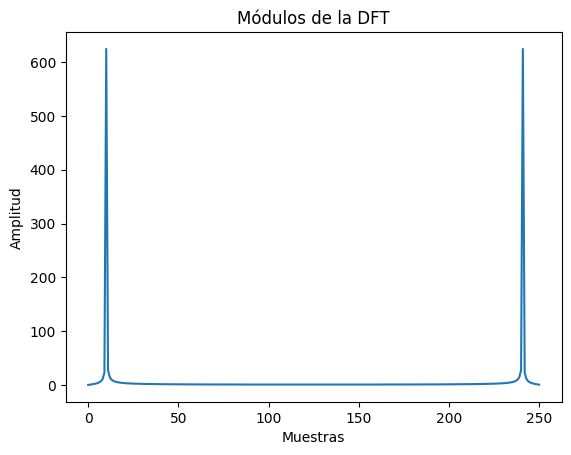

In [19]:
##Análisis de Fourier en tiempo discreto
X10 = np.fft.fft(x10)
plt.plot(abs(X10))
plt.title('Módulos de la DFT')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()


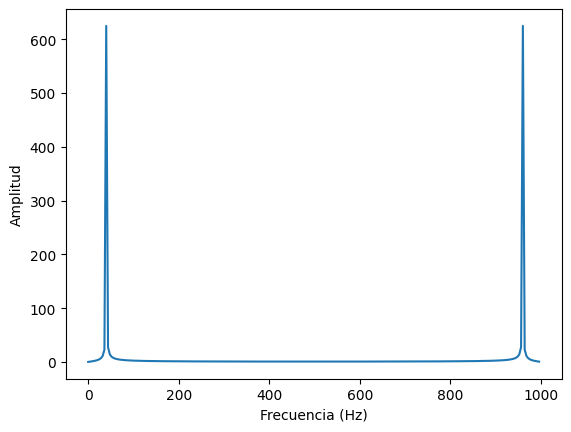

In [20]:
N = len(X10)
F = np.arange(0,N)*Fs/N
plt.plot(F,abs(X10))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.show()


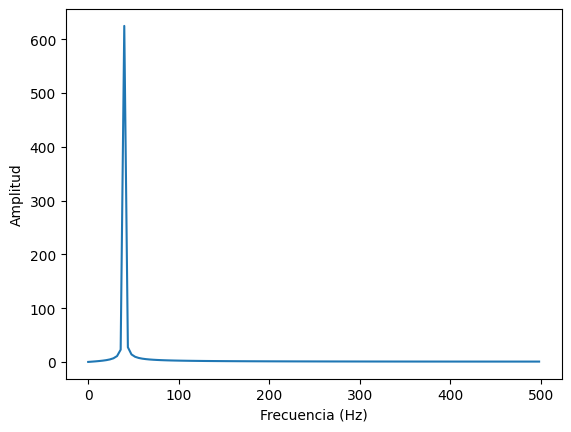

In [21]:
Nmitad = int(np.ceil(N/2))
Fmitad = np.arange(0,Nmitad)*Fs/N
X10mitad = X10[0:Nmitad]
plt.plot(Fmitad,abs(X10mitad))
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.show()


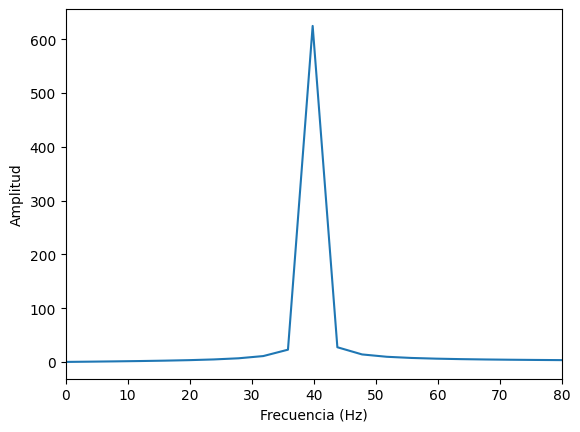

In [22]:
plt.plot(Fmitad,abs(X10mitad))
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.xlim(0,80)
plt.show()


**4.1	Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal, y utilice la frecuencia de muestreo necesaria para representarla apropiadamente**

Para la creación de la señal se tendrá en cuenta la señal del ejemplo de la practica, para esto se hará la suma de tres sinusoidades de diferentes frecuencias(40 Hz,80Hz y 160Hz).

Para representar correctamente la señal continua en tiempo discreto es necesario seleccionar una frecuencia de muestreo adecuada.Según el teorema de muestreo de Nyquist, la frecuencia de muestreo debe ser por lo menos el doble de la frecuencia máxima esto se realiza para evitar el fénomeno de aliasing, el cual puede producir una representación incorrecta de las componente frecuenciales.

En nuestro caso la frecuencia máxima de la señal es:

$f_s > 2 f_{max}$

por lo tanto, la frecuencia mínima requerida es: 

$
F_s \geq 2f_{max} = 2(160) = 320 \text{ Hz}
$

Aunque 320 Hz es el mínimo teórico, en la práctica se utilizará una frecuencia mayor para obtener una representación más precisa de la señal y mejorar el análisis espectral. Por esta razón se seleccionó una frecuencia de muestreo de 1000 Hz.







Frecuencia máxima de la señal : 160 Hz
Fs mínima requerida (Nyquist)  : Fs > 320 Hz
Fs utilizada                   : 1000 Hz


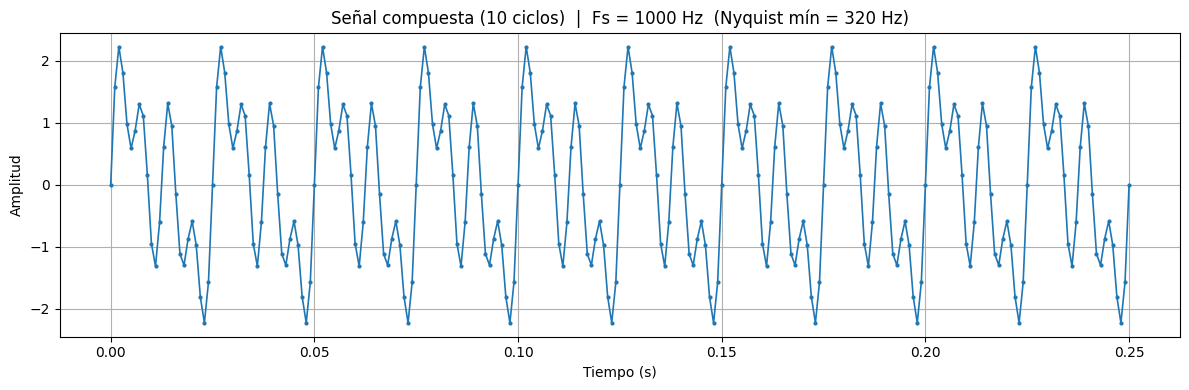

In [ ]:
# Frecuencias de las componentes
f1 = 40
f2 = 80
f3 = 160

# 1. Frecuencia mínima de muestreo (Nyquist)
f_max = f3
Fs_min = 2 * f_max          # = 320 Hz
print(f"Frecuencia máxima de la señal : {f_max} Hz")
print(f"Fs mínima requerida (Nyquist)  : Fs > {Fs_min} Hz")

# 2. Frecuencia de muestreo apropiada
Fs = 1000
T  = 1 / Fs
print(f"Fs utilizada                   : {Fs} Hz")

# 3. Tiempo: 10 ciclos de la componente más lenta (f1 = 40 Hz)
Tp = 10 / f1                # = 0.25 s
t  = np.arange(0, Tp + T, T)

# 4. Señal compuesta
x = (np.sin(2*np.pi*f1*t) +
     np.sin(2*np.pi*f2*t) +
     np.sin(2*np.pi*f3*t))

# 5. Gráfica
plt.figure(figsize=(12, 4))
plt.plot(t, x, marker='o', markersize=2, linewidth=1.2)
plt.title(f"Señal compuesta (10 ciclos)  |  Fs = {Fs} Hz  (Nyquist mín = {Fs_min} Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()